In [2]:
import numpy as np
import os
import torch
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from accelerate import Accelerator
from torch_ema import ExponentialMovingAverage as EMA
from torchvision import transforms as tf
import torch.distributed as dist

from wavediffusion.plain_unet import plainUnet, masked_training_loop_plain, evaluate_plain
from wavediffusion.wavedata import npyDataResized
# from wavediffusion.waveutils import evaluate, sample_and_save

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
train_batch_size=4
sample_batch_size=2
epochs=2
RESUME=False
path='/global/homes/j/jiarongw/scratch_folder/log1p/plain1/'
eval_everyn_step=100

In [4]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
train_file_names = [
    *( (f'wave_2010{i:02d}', f'forcing_2010{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2011{i:02d}', f'forcing_2011{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2012{i:02d}', f'forcing_2012{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2013{i:02d}', f'forcing_2013{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2014{i:02d}', f'forcing_2014{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2015{i:02d}', f'forcing_2015{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2016{i:02d}', f'forcing_2016{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2017{i:02d}', f'forcing_2017{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2018{i:02d}', f'forcing_2018{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2019{i:02d}', f'forcing_2019{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2020{i:02d}', f'forcing_2020{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2021{i:02d}', f'forcing_2021{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2022{i:02d}', f'forcing_2022{i:02d}') for i in range(1, 13) ),
]
train_file_list = [(os.path.join(train_file_path, f'{x}.npy'), 
                    os.path.join(train_file_path, f'{f}.npy')) for x, f in train_file_names]   
stats_file = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']
train = npyDataResized(
    train_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(train_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=1
)
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [('wave_200804', 'forcing_200804')]
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                    os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataResized(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=1
)

loader = DataLoader(train, batch_size=train_batch_size, shuffle=True)
loader_test = DataLoader(test, batch_size=sample_batch_size, shuffle=True)  # Used for generating samples during training  

In [5]:
model = plainUnet(in_dim=320, in_ch=3, out_ch=4, ch=256, 
                  ch_mult=(1, 2, 2), attn_resolutions=(16,))   

In [16]:
print(torch.cuda.is_available())
a = Accelerator(mixed_precision="fp16") 
print(a.state)

True
Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16



In [ ]:
# Train
log_file = open(path + "loss_log.txt", "w")
test_log_file = open(path + "test_loss_log.txt", "w")
ema = EMA(model.parameters(), decay=0.999)
start_epoch = 0

if RESUME and weights_file is not None:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])
    start_epoch = ckpt["epoch"]   # I can pass those to the training loop to count for epochs better
    # start_step = ckpt.get("step", 0)   # Same with steps
    # if a.is_main_process:
    #     print(f"Resuming from epoch {start_epoch}, step {start_step}")
          
ema.to(a.device)

train_iter = masked_training_loop_plain(loader, model, lr=1e-4, epochs=epochs, 
                                        accelerator=a, start_epoch=start_epoch)

last_epoch = -1

for ns in train_iter:
    # ---- logging (only main process) ----
    if a.is_main_process:
        log_file.write(f"{ns.step}, {ns.loss.item():.6f}\n")
        log_file.flush()
        ns.pbar.set_description(f"Loss={ns.loss.item():.5f}")        
        
    ema.update()

    # ---- evaluation ----
    if ns.step % eval_everyn_step == 0:
        a.wait_for_everyone()
        if a.is_main_process:     
            print('Evaluating... at step ', ns.step)
            val_loss = evaluate_plain(model, ema, loader_test, a) # Compute on all GPUs but gather
            test_log_file.write(f"{ns.step}, {val_loss.item():.6f}\n")
            test_log_file.flush()
        a.wait_for_everyone()

  0%|          | 0/2 [00:00<?, ?it/s]

Evaluating... at step  0


### Evaluate

In [20]:
path = '/global/homes/j/jiarongw/scratch_folder/log1p/plain1/'
weights_file = path + 'ckpt_6.pt'
a = Accelerator() 
model = plainUnet(in_dim=320, in_ch=3, out_ch=4, ch=256, 
                  ch_mult=(1, 2, 2), attn_resolutions=(16,))   
ema = EMA(model.parameters(), decay=0.999)

ema, model, loader_test = a.prepare(ema, model, loader_test)

if RESUME and weights_file is not None:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])

In [23]:
loader_iter = iter(loader_test) 
x, f, mask = next(loader_iter)
with torch.no_grad():
    with ema.average_parameters():
        y = model(f)
        x_ = train.invert_x(y[0])
        x_pred = x_ * tf.Resize((320,720))(mask[0])

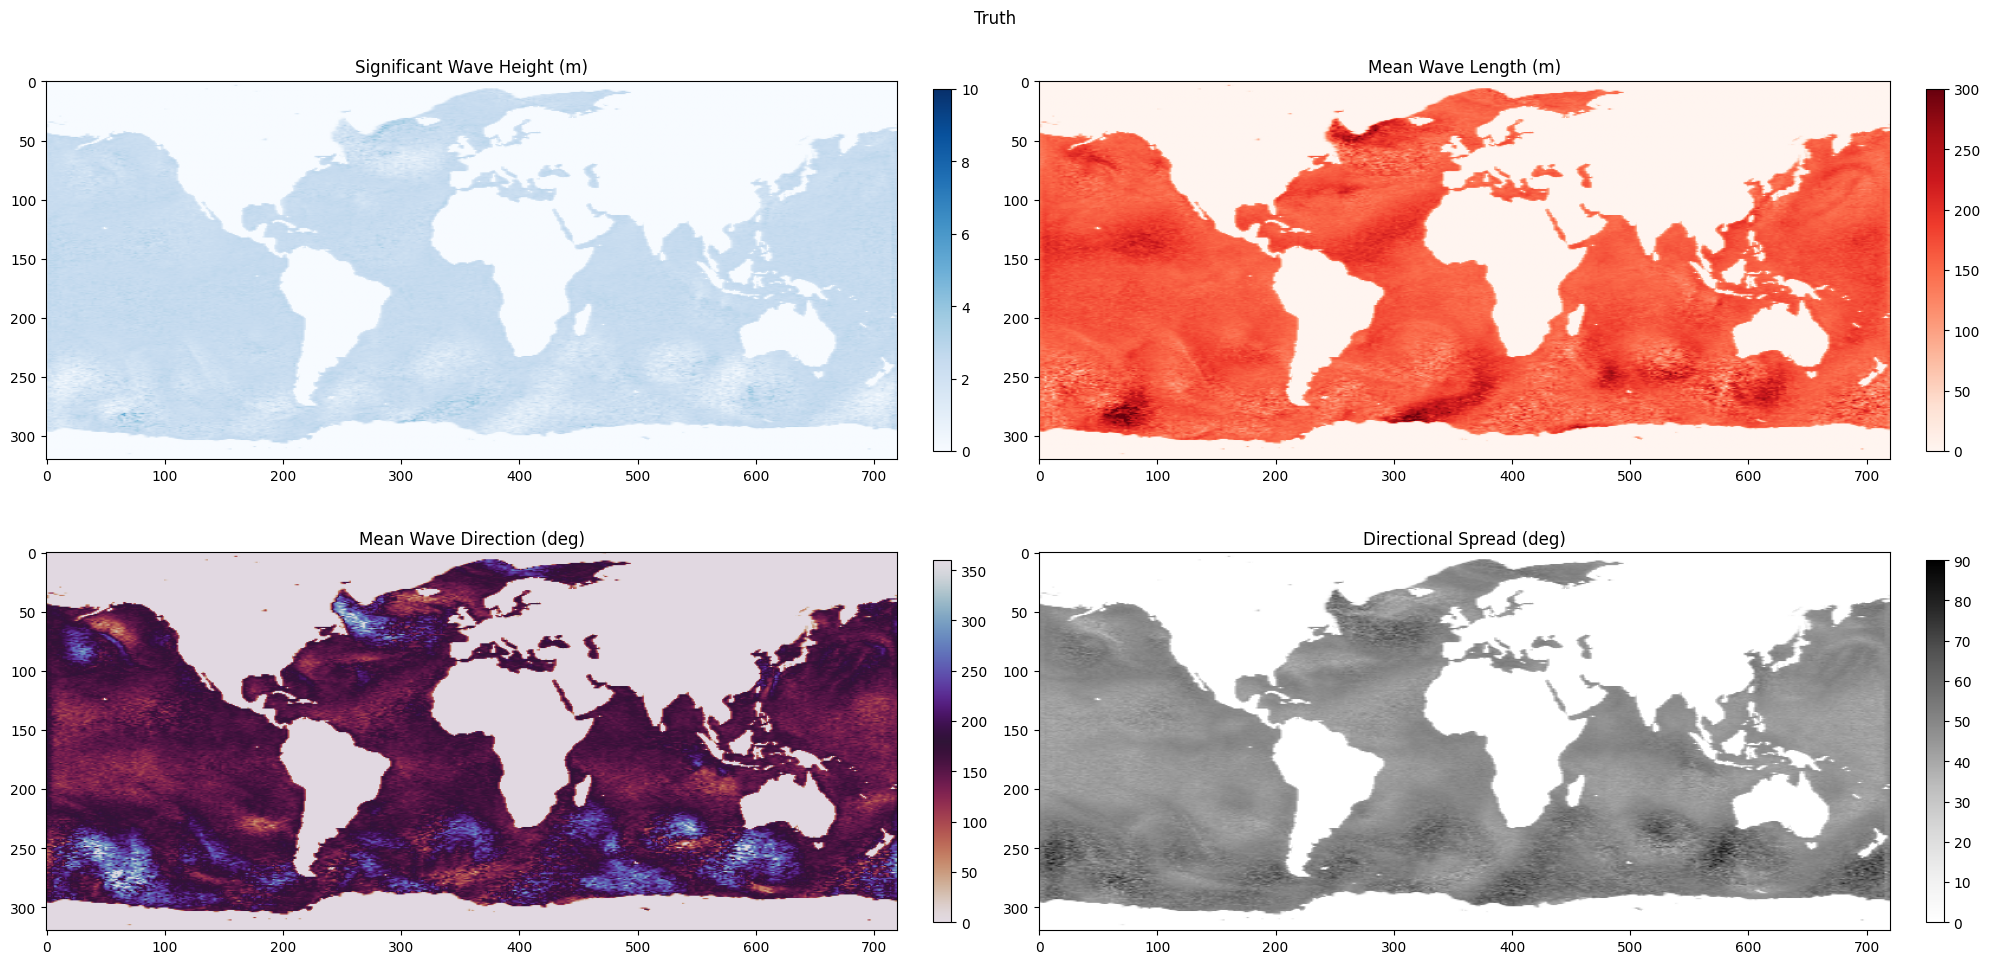

In [24]:
from torchvision import transforms as tf
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
img0 = axes[0,0].imshow(x_pred.cpu().numpy()[0,::-1], vmin=0, vmax=10, cmap='Blues')
img1 = axes[0,1].imshow(x_pred.cpu().numpy()[1,::-1], vmin=0, vmax=300, cmap='Reds')
img2 = axes[1,0].imshow(x_pred.cpu().numpy()[2,::-1], vmin=0, vmax=360, cmap='twilight_r')
img3 = axes[1,1].imshow(x_pred.cpu().numpy()[3,::-1], vmin=0, vmax=90, cmap='Greys')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img3, ax=axes[1,1], fraction=0.02, pad=0.04)
axes[0,0].set_title('Significant Wave Height (m)')
axes[0,1].set_title('Mean Wave Length (m)')
axes[1,0].set_title('Mean Wave Direction (deg)')
axes[1,1].set_title('Directional Spread (deg)')

plt.suptitle('Truth')
plt.tight_layout()
plt.show()